<a href="https://colab.research.google.com/github/lijoannali/butterfly-moths-classifier/blob/main/%5BFinal%5D_Butterfly_%2B_Moth_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network Approach - ResNet with Tweaks



In [ ]:
import numpy as np
from tqdm import tqdm
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import random
from pathlib import Path
import os
import zipfile

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils import data
from torch.utils.data import Dataset
from torchvision import transforms as T

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from PIL import Image
def show_image_subplot(images : list[np.ndarray], num_rows: int, num_cols: int,
                       titles: list[str] = [], axis: str = 'off' , dpi: int = 80,
                       cmap: str | None = None) -> None:
    """ shows a matplotlib subplot for multiple images"""
    assert num_rows > 1 or num_cols > 1 , "Please ensure that you have more than 1 row or col"
    assert len(images) == int(num_rows*num_cols), "Please ensure that number of images provided match rows x cols product"
    titles = titles + ["No Title" for _ in range(len(images)-len(titles))] if len(titles) < len(images) else titles[:len(images)]
    fig, axs = plt.subplots(nrows=num_rows, ncols=num_cols, dpi=dpi)
    axs_flat = axs.flatten()
    for (_ax, _im, _title) in zip(axs_flat, images, titles):
        _ax.imshow(_im, cmap=cmap)
        _ax.axis(axis)
        _ax.set_title(_title)
    plt.tight_layout()
    plt.show()

## Load in the dataset

In [ ]:
#Load dataset
BASE_DIR = "/content/drive/Shareddrives/Elec378_Final_Project/Elec378_FP_Code"
TEST_DIR = "/content/drive/Shareddrives/Elec378_Final_Project/Elec378_FP_Code/test_images"
CSV_PATH = "/content/drive/Shareddrives/Elec378_Final_Project/Elec378_FP_Code/train.csv"
TEST_IMG_DIR = "/content/drive/Shareddrives/Elec378_Final_Project/Elec378_FP_Code/test_images"
TRAIN_IMG_DIR = "/content/drive/Shareddrives/Elec378_Final_Project/Elec378_FP_Code/train_images2/train_images"


In [ ]:
RANDOM_STATE= 347
IMG_SIZE = 224

In [ ]:
# Load metadata
df = pd.read_csv(CSV_PATH)
class_counts = df['TARGET'].value_counts()
# Train/validation split with stratification
X_train_files, X_val_files, y_train, y_val = train_test_split(
    df["file_name"].values,
    df["TARGET"].values,
    test_size=0.0079,
    stratify=df["TARGET"].values,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train_files)}, Validation: {len(X_val_files)}")
# Loads the metadata from the csv file
def load_metadata():
    df = pd.read_csv(CSV_PATH)
    print(f"Loaded {len(df)} entries, {df['TARGET'].nunique()} classes")
    return df
# Loads the images
def load_image(filename, size, img_dir=TRAIN_IMG_DIR):
    path = os.path.join(img_dir, filename)
    img = Image.open(path).convert("RGB").resize((size, size))
    return np.array(img)
# This loads one image and its label of your choice.
# Input: the dataframe, the index of the image, and the size of the image.
def load_image_label_pair(df, index, size=224):
    row = df.iloc[index]
    img = load_image(row["file_name"], size)
    label = row["TARGET"]
    return img, label
def explore_batch(df, batch_size=12):
    batch = df.sample(batch_size)
    images, titles = [], []
    for idx, row in batch.iterrows():
        img, label = load_image_label_pair(df, idx)
        images.append(img)
        titles.append(f"{label}")
    show_image_subplot(images, 3, 4, titles=titles)

def explore_histograms(df, batch_size=100):
    batch = df.sample(batch_size).sort_values("TARGET")
    fig, axs = plt.subplots(50, 2, figsize=(12, 80))
    for ax, (idx, row) in zip(axs.flatten(), batch.iterrows()):
        img, label = load_image_label_pair(df, idx)
        ax.hist(img.flatten(), bins=50, color='steelblue', alpha=0.7)
        ax.set_title(label, fontsize=8)
        ax.set_xlim(0, 255)
    # plt.tight_layout()
    plt.show()

Train: 12494, Validation: 100


## Examine the Data

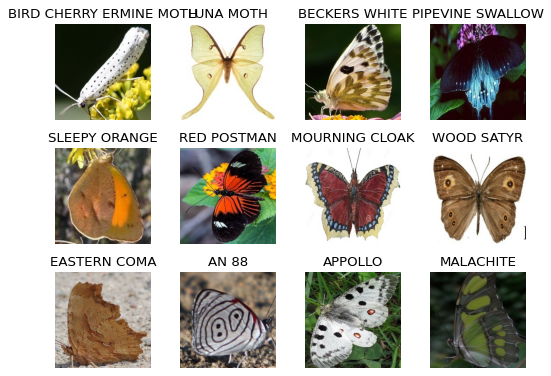

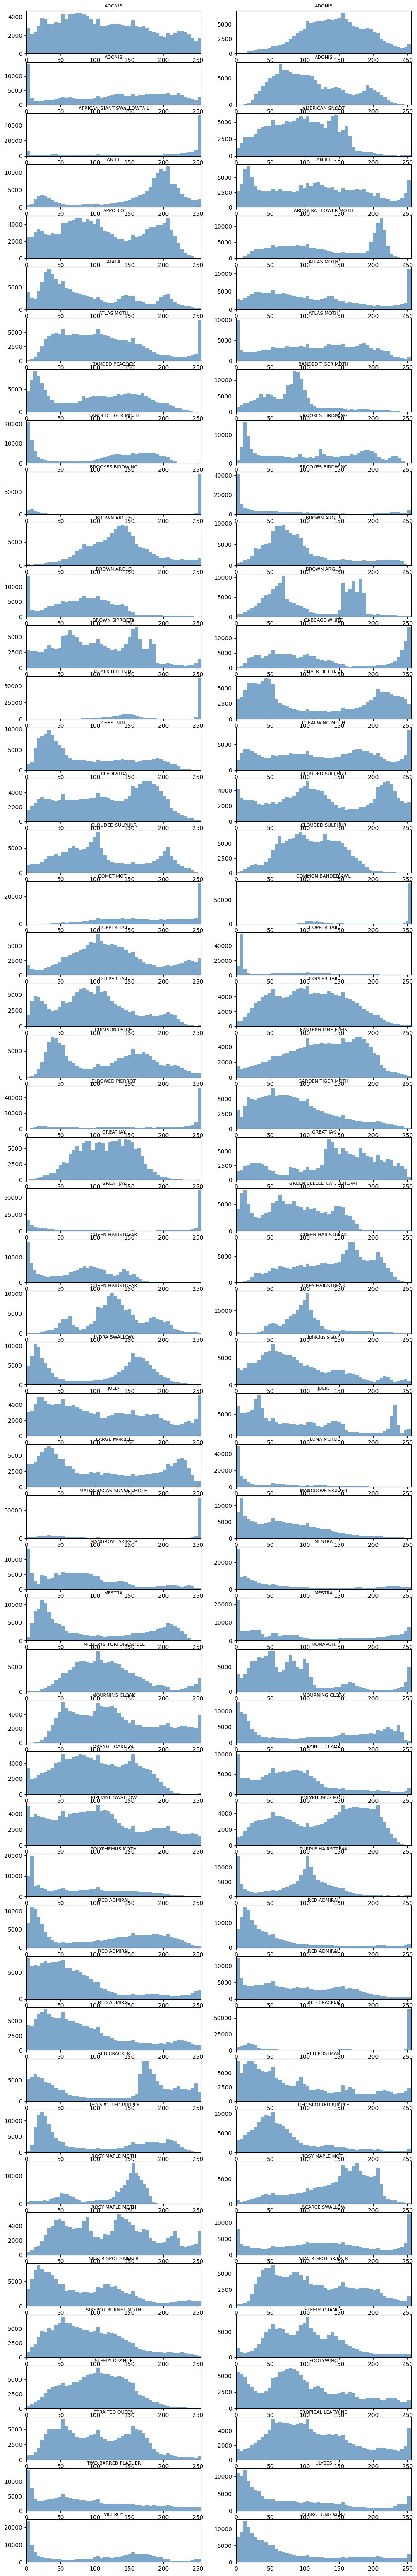

Length of data  12594


In [ ]:
explore_batch(df)
explore_histograms(df, batch_size=100)
print("Length of data ", len(df))


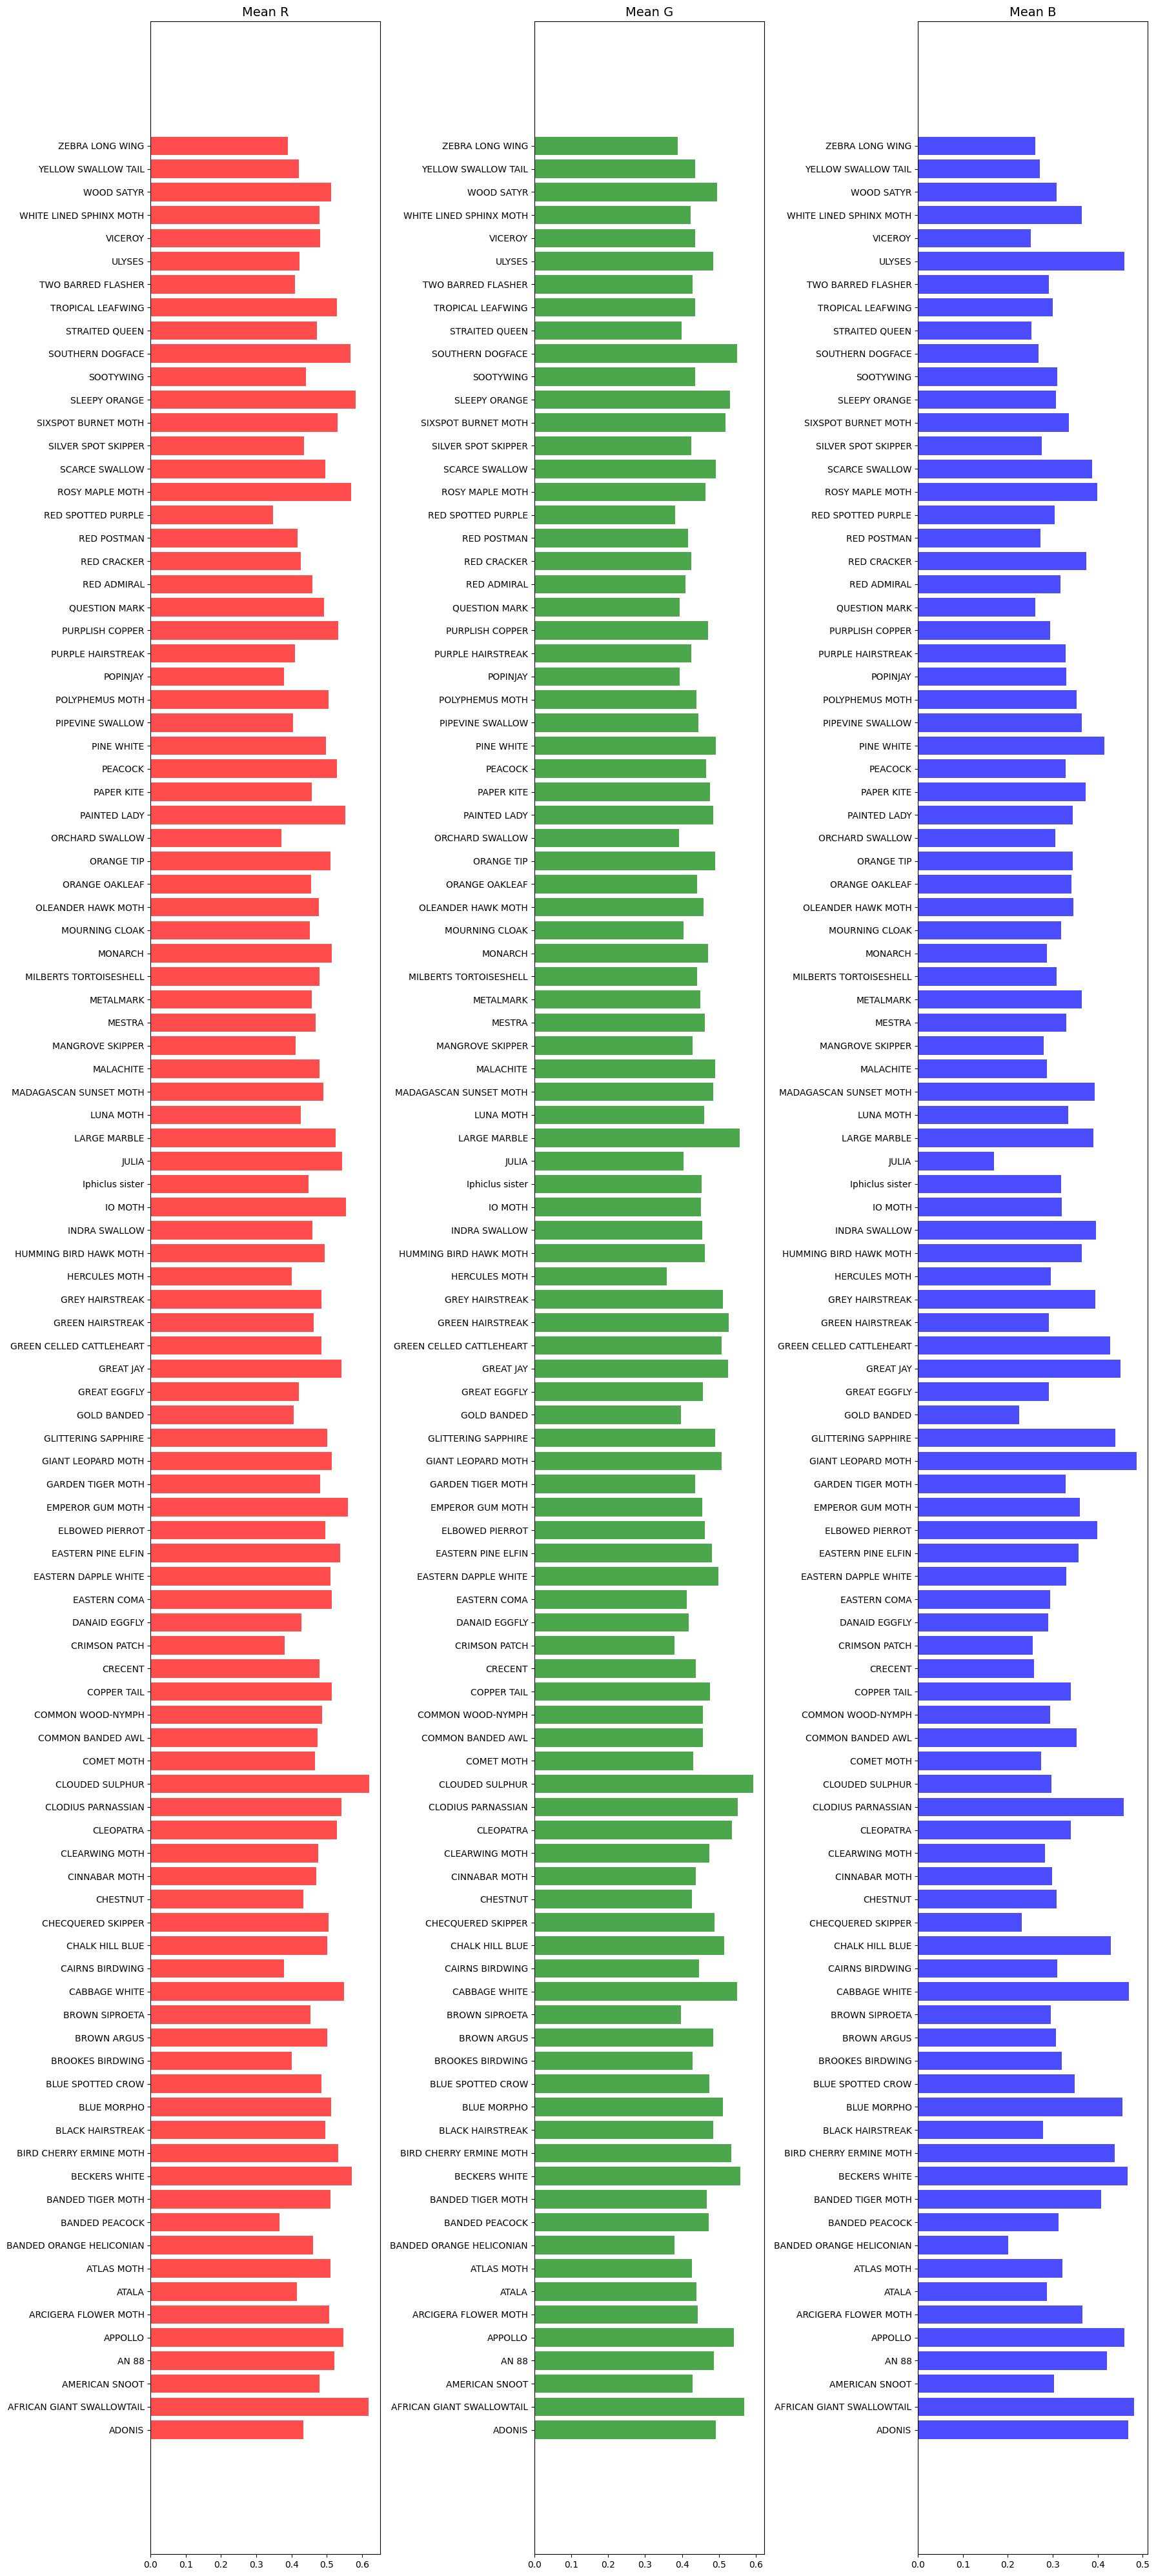

In [ ]:
def mean_rgb_per_class(df, sample_per_class=20):
    results = {}
    for label, group in df.groupby("TARGET"):
        batch = group.sample(min(sample_per_class, len(group)))
        means = [load_image_label_pair(df, idx)[0].mean(axis=(0,1)) for idx, _ in batch.iterrows()]
        results[label] = np.mean(means, axis=0)

    labels, rgb = zip(*sorted(results.items()))
    rgb = np.array(rgb) / 255.0

    n = len(labels)
    fig, axs = plt.subplots(1, 3, figsize=(18, n * 0.4))
    for i, (channel, color) in enumerate(zip(["R", "G", "B"], ["red", "green", "blue"])):
        axs[i].barh(labels, [c[i] for c in rgb], color=color, alpha=0.7)
        axs[i].set_title(f"Mean {channel}", fontsize=14)
        axs[i].tick_params(labelsize=10)
    plt.tight_layout()
    plt.show()

mean_rgb_per_class(df)

## Model Implementation

In [ ]:
class BugsDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.transform = transform
        self.X = images  # now file paths
        self.y = labels

    def __getitem__(self, idx): #FOR TRAINING
        img = load_image(self.X[idx], IMG_SIZE)
        label = torch.LongTensor([self.y[idx]])
        img = self.transform(img)
        return img, label

    def __len__(self):
        assert len(self.X) == len(self.y), "Number of images and number of labels must match"
        return len(self.X)

In [ ]:
batch_size = 64

train_transform = T.Compose([
    T.ToTensor(),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=30, fill=0),
    T.ColorJitter(brightness = 0.3, contrast= 0.3),
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomGrayscale(p=0.1),
    T.RandomErasing(p=0.2),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #Check on these values
])

val_transform = T.Compose([
    T.ToTensor(),
    T.CenterCrop(IMG_SIZE - 40), #crop to remove background edges
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#Convert string labels to ints
le = LabelEncoder()
y_train = le.fit_transform(y_train)  # Convert string class names to integer labels
y_val   = le.transform(y_val)        # transform val with same mapping

train_dataset = BugsDataset(X_train_files, y_train, train_transform)
train_dataloader = data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

transform = T.Compose([T.ToTensor()])
val_dataset   = BugsDataset(X_val_files,   y_val,   val_transform)
val_dataloader = data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
NUM_CLASSES = 100
class ConvBlock(nn.Module):
  def __init__(self, in_chan, out_chan, kernel_size, padding):
    super().__init__()
    self.conv = nn.Conv2d(in_chan, out_chan, kernel_size, padding=padding)
    self.relu = nn.ReLU()
  def forward(self, x):
    return self.relu(self.conv(x))

class MaxPool(nn.Module):
  def __init__(self, kernel_size=2):
    super().__init__()
    self.kernel_size = kernel_size
  def forward(self, x):
    return F.max_pool2d(x, self.kernel_size)

class ResNetBlockV2(nn.Module):
    def __init__(self, in_chan, out_chan, stride=1):
        super().__init__()
        self.bn1   = nn.BatchNorm2d(in_chan)
        self.relu  = nn.ReLU()
        self.conv1 = nn.Conv2d(in_chan, out_chan, 3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_chan)
        self.conv2 = nn.Conv2d(out_chan, out_chan, 3, stride=1, padding=1, bias=False)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_chan != out_chan:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_chan, out_chan, 1, stride=stride, bias=False)
            )

    def forward(self, x):
        out = self.conv1(self.relu(self.bn1(x)))
        out = self.conv2(self.relu(self.bn2(out)))
        out = out + self.shortcut(x)
        return out
#NN_4
class Model(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        self.dropout_rate = dropout_rate
        self.main = nn.Sequential(
            ConvBlock(3, 32, 3, 1),
            MaxPool(2),                       # 112x112
            ResNetBlockV2(32, 64, stride=1),
            MaxPool(2),                       # 56x56
            ResNetBlockV2(64, 128, stride=1),
            MaxPool(2),                       # 28x28
            ResNetBlockV2(128, 256, stride=1),
            MaxPool(2),                       # 14x14
            ResNetBlockV2(256, 256, stride=1),
        )
        # New pooling method for NN_3
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.lin = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.main(x)
        x = self.pool(x)
        x = self.lin(x)
        return x

In [ ]:
#Training Loop
def train_loop(dataloader, model, loss_fn, optimizer, scheduler, batch_size, epoch):
    size = len(dataloader.dataset)
    model.train()
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    for batch, (X, y) in enumerate(dataloader):
        X = X.to('cuda')
        y = y.squeeze().to('cuda')
        #calculate loss in forward
        pred = model(X)
        loss = loss_fn(pred, y)
        #backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step(epoch + batch / len(dataloader))

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")
        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

#Runs at end of every epoch
def val_loop(dataloader, model, loss_fn):
  model.eval()
  val_loss = 0
  progress_bar = tqdm(dataloader, desc="Validation", leave=False)
  with torch.no_grad():
      for batch, (X, y) in enumerate(dataloader):
          X = X.to('cuda')
          y = y.squeeze().to('cuda')
          pred = model(X)
          loss = loss_fn(pred, y)
          val_loss += loss.item()
          # progress_bar.set_postfix(loss=f"{loss.item():.4f}")

  return val_loss / len(dataloader)



In [ ]:
ESWQRD\=

In [ ]:
MODEL_SAVE_PATH = '/content/drive/Shareddrives/Elec378_Final_Project/Elec378_FP_Code/models/NN_4'
#Initialize model and hyperparameters
learning_rate = 1e-3
num_epochs = 100     # default = 100
dropout_rate = 0.0 #higher is less overfitting
resume_epoch = 0

model = Model(dropout_rate=dropout_rate)
model.to('cuda')
loss_fn = nn.CrossEntropyLoss() #for Classification tasks
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

# Resume from checkpoint if given an epoch to resume at
if resume_epoch > 0:
    checkpoint_path = f'{MODEL_SAVE_PATH}/model{resume_epoch-1}.params'
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    best_val_loss = checkpoint['best_val_loss']
    validation_losses = checkpoint['validation_losses']
    print(f"Resumed from epoch {resume_epoch}, best val loss: {best_val_loss:.3f}")

validation_losses = []
best_val_loss = float('inf')

#Call training and validation loop
for epoch in range(resume_epoch, num_epochs):
  print(f"Epoch {epoch+1}")
  train_loop(train_dataloader, model, loss_fn, optimizer, scheduler, batch_size=batch_size, epoch=epoch)
  val_loss = (val_loop(val_dataloader, model, loss_fn))
  print(f"Val Loss: {val_loss:.3f}")
  validation_losses.append(val_loss)
  # Save model if validation loss improves
  if val_loss < best_val_loss:
      best_val_loss = val_loss
      # log the best val loss
      torch.save({
          'model_state_dict': model.state_dict(),
          'best_val_loss': best_val_loss,
          'validation_losses': validation_losses,
          'epoch': epoch
      }, f'{MODEL_SAVE_PATH}/model%d.params' % epoch)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total # of parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total # of trainable parameters: {trainable_params}")

#Cuts the runtime after training finishes
from google.colab import runtime
# runtime.unassign()

Epoch 1




Training:   0%|          | 0/196 [00:00<?, ?it/s]

Training:   0%|          | 0/196 [00:07<?, ?it/s, loss=4.6663]

loss: 4.666259  [   64/12494]




Training:   0%|          | 0/196 [00:07<?, ?it/s, loss=5.9506]

Training:   0%|          | 0/196 [00:08<?, ?it/s, loss=5.6268]

Training:   0%|          | 0/196 [00:08<?, ?it/s, loss=5.4540]

Training:   0%|          | 0/196 [00:11<?, ?it/s, loss=5.1228]

Training:   0%|          | 0/196 [00:13<?, ?it/s, loss=4.8602]

Training:   0%|          | 0/196 [00:13<?, ?it/s, loss=5.2388]

Training:   0%|          | 0/196 [00:13<?, ?it/s, loss=5.3080]

Training:   0%|          | 0/196 [00:17<?, ?it/s, loss=5.2105]

Training:   0%|          | 0/196 [00:17<?, ?it/s, loss=4.8484]

Training:   0%|          | 0/196 [00:18<?, ?it/s, loss=5.0745]

Training:   0%|          | 0/196 [00:18<?, ?it/s, loss=5.1600]

Training:   0%|          | 0/196 [00:21<?, ?it/s, loss=4.9416]

Training:   0%|          | 0/196 [00:22<?, ?it/s, loss=5.3996]

Training:   0%|          | 0/196 [00:22<?, ?it/s, loss=4.5996]

Training:   0%|          | 0/196 [00:22<?, ?it/s, loss=5.1483]

Training:   0%|          | 0/196 [00:2

loss: 3.825109  [ 6464/12494]


...

loss: 0.086838  [   64/12494]




Training:   0%|          | 0/196 [00:03<?, ?it/s, loss=0.1280]

Training:   0%|          | 0/196 [00:04<?, ?it/s, loss=0.1954]

Training:   0%|          | 0/196 [00:04<?, ?it/s, loss=0.1679]

Training:   0%|          | 0/196 [00:07<?, ?it/s, loss=0.0951]

Training:   0%|          | 0/196 [00:07<?, ?it/s, loss=0.2387]

Training:   0%|          | 0/196 [00:07<?, ?it/s, loss=0.1353]

Training:   0%|          | 0/196 [00:08<?, ?it/s, loss=0.2840]

Training:   0%|          | 0/196 [00:09<?, ?it/s, loss=0.2854]

Training:   0%|          | 0/196 [00:10<?, ?it/s, loss=0.2101]

Training:   0%|          | 0/196 [00:10<?, ?it/s, loss=0.3014]

Training:   0%|          | 0/196 [00:10<?, ?it/s, loss=0.5324]

Training:   0%|          | 0/196 [00:12<?, ?it/s, loss=0.3837]

Training:   0%|          | 0/196 [00:12<?, ?it/s, loss=0.1301]

Training:   0%|          | 0/196 [00:13<?, ?it/s, loss=0.1797]

Training:   0%|          | 0/196 [00:13<?, ?it/s, loss=0.2090]

Training:   0%|          | 0/196 [00:1

loss: 0.141439  [ 6464/12494]




Training:   0%|          | 0/196 [01:17<?, ?it/s, loss=0.2352]

Training:   0%|          | 0/196 [01:18<?, ?it/s, loss=0.2561]

Training:   0%|          | 0/196 [01:18<?, ?it/s, loss=0.1345]

Training:   0%|          | 0/196 [01:20<?, ?it/s, loss=0.1823]

Training:   0%|          | 0/196 [01:21<?, ?it/s, loss=0.2118]

Training:   0%|          | 0/196 [01:21<?, ?it/s, loss=0.1362]

Training:   0%|          | 0/196 [01:21<?, ?it/s, loss=0.1128]

Training:   0%|          | 0/196 [01:24<?, ?it/s, loss=0.2309]

Training:   0%|          | 0/196 [01:24<?, ?it/s, loss=0.1420]

Training:   0%|          | 0/196 [01:25<?, ?it/s, loss=0.1655]

Training:   0%|          | 0/196 [01:25<?, ?it/s, loss=0.0568]

Training:   0%|          | 0/196 [01:27<?, ?it/s, loss=0.0999]

Training:   0%|          | 0/196 [01:27<?, ?it/s, loss=0.0987]

Training:   0%|          | 0/196 [01:28<?, ?it/s, loss=0.2359]

Training:   0%|          | 0/196 [01:28<?, ?it/s, loss=0.3015]

Training:   0%|          | 0/196 [01:2

Val Loss: 0.534
Total # of parameters: 2412836
Total # of trainable parameters: 2412836


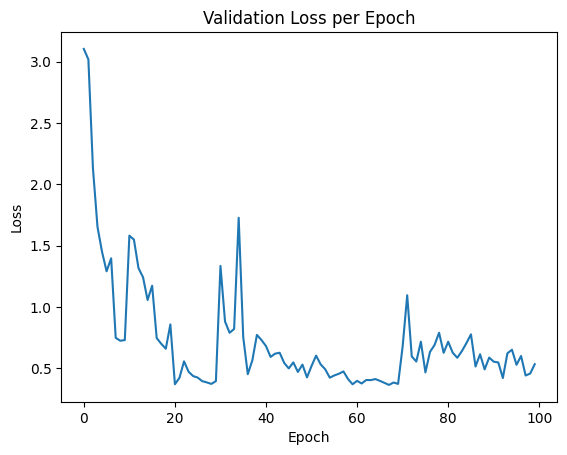

The best model was the one saved in Epoch 68
It had the lowest validation loss: 0.36491718143224716
Epoch 1: 3.10490345954895
Epoch 2: 3.0192840099334717
Epoch 3: 2.133607864379883
Epoch 4: 1.6539422273635864
Epoch 5: 1.449799120426178
Epoch 6: 1.2914950847625732
Epoch 7: 1.3974735140800476
Epoch 8: 0.7488390505313873
Epoch 9: 0.7250050902366638
Epoch 10: 0.7307597398757935
Epoch 11: 1.582294762134552
Epoch 12: 1.5499303936958313
Epoch 13: 1.317763090133667
Epoch 14: 1.242983877658844
Epoch 15: 1.0574317574501038
Epoch 16: 1.1739083528518677
Epoch 17: 0.7469516694545746
Epoch 18: 0.700323075056076
Epoch 19: 0.6602346897125244
Epoch 20: 0.8581217527389526
Epoch 21: 0.3703087717294693
Epoch 22: 0.42298245429992676
Epoch 23: 0.5573044866323471
Epoch 24: 0.47222551703453064
Epoch 25: 0.43706850707530975
Epoch 26: 0.424723744392395
Epoch 27: 0.39553335309028625
Epoch 28: 0.38556480407714844
Epoch 29: 0.37314094603061676
Epoch 30: 0.3961202949285507
Epoch 31: 1.335088312625885
Epoch 32: 0.88

In [ ]:
# Plot validation losses
plt.plot(validation_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss per Epoch')
plt.show()

print(f"The best model was the one saved in Epoch {validation_losses.index(min(validation_losses))+1}")
print(f"It had the lowest validation loss: {min(validation_losses)}")
for i, loss in enumerate(validation_losses): print(f"Epoch {i+1}: {loss}")

# Make a Prediction For Submission


In [ ]:
class BugsDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.transform = transform
        self.X = images  # now file paths
        self.y = labels

    def __getitem__(self, idx): #FOR TESTING/PRED
      img = self.X[idx]  #returns a numpy array
      label = torch.LongTensor([self.y[idx]])
      img = self.transform(img)
      return img, label

    def __len__(self):
        assert len(self.X) == len(self.y), "Number of images and number of labels must match"
        return len(self.X)

In [ ]:
# Testing the best model
SAVED_MODEL_PATH = '/content/drive/Shareddrives/Elec378_Final_Project/Elec378_FP_Code/models/NN_4/model67.params'   # Change this to best model file path
checkpoint = torch.load(SAVED_MODEL_PATH)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [ ]:
# Load test images
test_files = sorted([f for f in os.listdir("/content/drive/Shareddrives/Elec378_Final_Project/Elec378_FP_Code/test_images") if f.endswith(('.jpg', '.jpeg', '.png'))])
X_test = [np.array(Image.open(os.path.join(TEST_DIR, f)).convert("RGB").resize((IMG_SIZE, IMG_SIZE))) for f in test_files]
dummy_labels = [0] * len(X_test)

test_dataset = BugsDataset(X_test, dummy_labels, val_transform)
test_dataloader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Run inference
model.eval()
predictions = []
with torch.no_grad():
    for X, _ in test_dataloader:
        X = X.to('cuda')
        outputs = model(X)
        _, predicted = torch.max(outputs, dim=1)
        predictions.extend(predicted.cpu().numpy())

# Convert integer predictions back to string class names
predicted_names = le.inverse_transform(predictions)

# Strip file extensions for the ID column
ids = [os.path.splitext(f)[0] for f in test_files]

# Save submission
submission = pd.DataFrame({'ID': ids, 'TARGET': predicted_names})
submission.to_csv('/content/drive/Shareddrives/Elec378_Final_Project/Elec378_FP_Code/submissions/submission_NN4_model67.csv', index=False)
print(submission.head())

print(type(X_test[0]))  # should be numpy.ndarray
print(X_test[0].shape)  # should be (224, 224, 3)

print(type(test_files[0]), test_files[0])  # verify before doing anything

X_test = [np.array(Image.open(os.path.join(TEST_DIR, f)).convert("RGB").resize((IMG_SIZE, IMG_SIZE))) for f in test_files]
dummy_labels = [0] * len(X_test)

test_dataset = BugsDataset(X_test, dummy_labels, val_transform)
test_dataloader = data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print(type(X_test[0]), X_test[0].shape)

            ID  TARGET
0  test_000001  ADONIS
1  test_000002  ADONIS
2  test_000003  ADONIS
3  test_000004  ADONIS
4  test_000005  ADONIS
<class 'numpy.ndarray'>
(224, 224, 3)
<class 'str'> test_000001.jpg
<class 'numpy.ndarray'> (224, 224, 3)


# Cross Validation to Prevent Overfitting

In [ ]:
print(type(X_train_files))
print(X_train_files[:3])

<class 'numpy.ndarray'>
['train_003891.jpg' 'train_003941.jpg' 'train_001471.jpg']


In [ ]:
from sklearn.model_selection import KFold
# Combine train and val data
full_files = np.concatenate([X_train_files, X_val_files], axis=0)
full_labels = np.concatenate([y_train, y_val], axis=0)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(full_files)):
    print(f"\nFold {fold+1}/5")

    train_loader = data.DataLoader(BugsDataset(full_files[train_idx], full_labels[train_idx], train_transform),
                              batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader   = data.DataLoader(BugsDataset(full_files[val_idx], full_labels[val_idx], val_transform),
                              batch_size=batch_size, shuffle=False, num_workers=4)

    model = Model(dropout_rate=dropout_rate).to('cuda')
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)

    for epoch in range(num_epochs):
        train_loop(train_loader, model, loss_fn, optimizer, scheduler, batch_size, epoch)
        val_loss = val_loop(val_loader, model, loss_fn)
        print(f"Epoch {epoch+1} Val Loss: {val_loss:.3f}")


Fold 1/5


Training:   0%|          | 0/158 [00:00<?, ?it/s, loss=4.6497]

loss: 4.649697  [   64/10075]


Training:   0%|          | 0/158 [00:31<?, ?it/s, loss=4.0038]

loss: 4.003803  [ 6464/10075]


Training:   0%|          | 0/158 [00:36<?, ?it/s, loss=3.6338]

KeyboardInterrupt: 